<a href="https://colab.research.google.com/github/hiromimi0705-cpu/pioneer_research/blob/main/EDA_and_Statistical_Test_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3: Exploratory Data Analysis and Statistical Testing

## Project and Dataset Overview

This project investigates factors that may influence real estate transaction prices in Japan. Understanding these factors can help identify patterns in the housing market and provide insight into how property characteristics relate to transaction prices.

Dataset Name: Japan Real Estate Transaction Prices

Source: Kaggle

Link: https://www.kaggle.com/datasets/nishiodens/japan-real-estate-transaction-prices

Each row in the dataset represents a real estate transaction in Tokyo.

## Initial Exploratory Questions

1. How are property transaction prices distributed in Tokyo?
2. Is there a relationship between property area and transaction price?
3. Does travel time to the nearest station relate to transaction price?

## Statistical tests

In [6]:
from google.colab import files

uploaded = files.upload()

Saving 13.csv to 13 (1).csv


In [7]:
import pandas as pd

df = pd.read_csv("13.csv")

df.head()

,No,Type,Region,MunicipalityCode,Prefecture,Municipality,DistrictName,NearestStation,TimeToNearestStation,MinTimeToNearestStation,...,Classification,Breadth,CityPlanning,CoverageRatio,FloorAreaRatio,Period,Year,Quarter,Renovation,Remarks
0,1,"Pre-owned Condominiums, etc.",NaN,13101,Tokyo,Chiyoda Ward,Iidabashi,Iidabashi,4,4.0,...,NaN,NaN,Commercial Zone,80.0,500.0,3rd quarter 2019,2019,3,Not yet,NaN
1,2,"Pre-owned Condominiums, etc.",NaN,13101,Tokyo,Chiyoda Ward,Iidabashi,Iidabashi,4,4.0,...,NaN,NaN,Commercial Zone,80.0,500.0,3rd quarter 2019,2019,3,Done,NaN
2,3,Residential Land(Land and Building),Commercial Area,13101,Tokyo,Chiyoda Ward,Iidabashi,Iidabashi,2,2.0,...,Ward Road,4.0,Commercial Zone,80.0,500.0,2nd quarter 2019,2019,2,NaN,NaN
3,4,Residential Land(Land and Building),Commercial Area,13101,Tokyo,Chiyoda Ward,Iidabashi,Iidabashi,1,1.0,...,Tokyo Metropolitan Road,27.0,Commercial Zone,80.0,700.0,2nd quarter 2019,2019,2,NaN,NaN
4,5,"Pre-owned Condominiums, etc.",NaN,13101,Tokyo,Chiyoda Ward,Iidabashi,Iidabashi,4,4.0,...,NaN,NaN,Commercial Zone,80.0,500.0,2nd quarter 2019,2019,2,Done,NaN


In [8]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(406575, 38)

Columns:
['No', 'Type', 'Region', 'MunicipalityCode', 'Prefecture', 'Municipality', 'DistrictName', 'NearestStation', 'TimeToNearestStation', 'MinTimeToNearestStation', 'MaxTimeToNearestStation', 'TradePrice', 'FloorPlan', 'Area', 'AreaIsGreaterFlag', 'UnitPrice', 'PricePerTsubo', 'LandShape', 'Frontage', 'FrontageIsGreaterFlag', 'TotalFloorArea', 'TotalFloorAreaIsGreaterFlag', 'BuildingYear', 'PrewarBuilding', 'Structure', 'Use', 'Purpose', 'Direction', 'Classification', 'Breadth', 'CityPlanning', 'CoverageRatio', 'FloorAreaRatio', 'Period', 'Year', 'Quarter', 'Renovation', 'Remarks']

Data Types:
No                               int64
Type                            object
Region                          object
MunicipalityCode                 int64
Prefecture                      object
Municipality                    object
DistrictName                    object
NearestStation                  object
TimeToNearestStation            object
MinTimeToNearestStatio

Several variables contain substantial missing values. However, TradePrice and Area contain no missing values and were therefore selected for further analysis.

In [9]:
df.describe()

,No,MunicipalityCode,MinTimeToNearestStation,MaxTimeToNearestStation,TradePrice,Area,AreaIsGreaterFlag,UnitPrice,PricePerTsubo,Frontage,TotalFloorArea,TotalFloorAreaIsGreaterFlag,BuildingYear,PrewarBuilding,Breadth,CoverageRatio,FloorAreaRatio,Year,Quarter
count,406575.000000,406575.000000,396236.000000,396086.000000,4.065750e+05,406575.000000,406575.000000,7.950300e+04,7.950300e+04,202887.000000,136425.000000,406575.000000,314296.000000,406575.000000,217602.000000,400660.000000,400660.000000,406575.000000,406575.000000
mean,203288.000000,13139.899037,10.202352,11.132226,6.559070e+07,117.087425,0.003534,4.244468e+05,1.402837e+06,9.628389,172.495254,0.003015,1997.939315,0.000762,6.245105,62.130085,265.398517,2012.579836,2.500687
std,117368.237185,46.182357,7.980606,11.628337,3.092895e+08,204.205609,0.059346,4.665602e+05,1.539858e+06,6.617539,267.770785,0.054830,14.106049,0.027602,4.868474,13.136797,159.670705,3.902094,1.119079
min,1.000000,13101.000000,0.000000,0.000000,5.000000e+02,10.000000,0.000000,4.000000e+00,1.300000e+01,0.400000,10.000000,0.000000,1945.000000,0.000000,1.000000,30.000000,50.000000,2005.000000,1.000000
25%,101644.500000,13110.000000,5.000000,5.000000,2.100000e+07,50.000000,0.000000,2.000000e+05,6.700000e+05,5.900000,85.000000,0.000000,1988.000000,0.000000,4.000000,60.000000,150.000000,2009.000000,1.000000
50%,203288.000000,13117.000000,8.000000,8.000000,3.500000e+07,70.000000,0.000000,3.400000e+05,1.100000e+06,8.000000,95.000000,0.000000,2001.000000,0.000000,5.000000,60.000000,200.000000,2013.000000,3.000000
75%,304931.500000,13201.000000,13.000000,13.000000,5.400000e+07,115.000000,0.000000,5.400000e+05,1.800000e+06,11.300000,120.000000,0.000000,2009.000000,0.000000,6.000000,80.000000,300.000000,2016.000000,3.000000
max,406575.000000,13421.000000,120.000000,120.000000,6.100000e+10,5000.000000,1.000000,2.000000e+07,6.600000e+07,50.000000,2000.000000,1.000000,2020.000000,1.000000,90.000000,80.000000,1300.000000,2019.000000,4.000000


In [10]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['No', 'MunicipalityCode', 'MinTimeToNearestStation',
       'MaxTimeToNearestStation', 'TradePrice', 'Area', 'AreaIsGreaterFlag',
       'UnitPrice', 'PricePerTsubo', 'Frontage', 'TotalFloorArea',
       'TotalFloorAreaIsGreaterFlag', 'BuildingYear', 'PrewarBuilding',
       'Breadth', 'CoverageRatio', 'FloorAreaRatio', 'Year', 'Quarter'],
      dtype='object')

In [15]:
df[['TradePrice','Area']].describe()

,TradePrice,Area
count,4.065750e+05,406575.000000
mean,6.559070e+07,117.087425
std,3.092895e+08,204.205609
min,5.000000e+02,10.000000
25%,2.100000e+07,50.000000
50%,3.500000e+07,70.000000
75%,5.400000e+07,115.000000
max,6.100000e+10,5000.000000


Summary statistics were calculated for TradePrice and Area. The statistics provide information about the average, spread, and range of property prices and property sizes in the dataset.

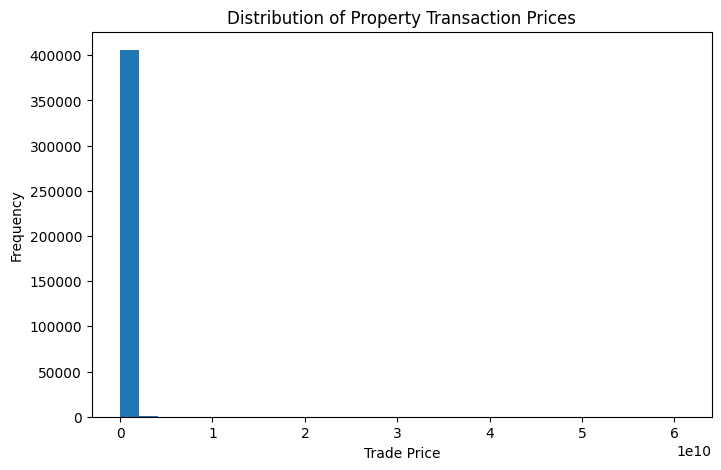

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['TradePrice'], bins=30)

plt.title('Distribution of Property Transaction Prices')
plt.xlabel('Trade Price')
plt.ylabel('Frequency')

plt.show()

This histogram shows the distribution of transaction prices in the dataset.

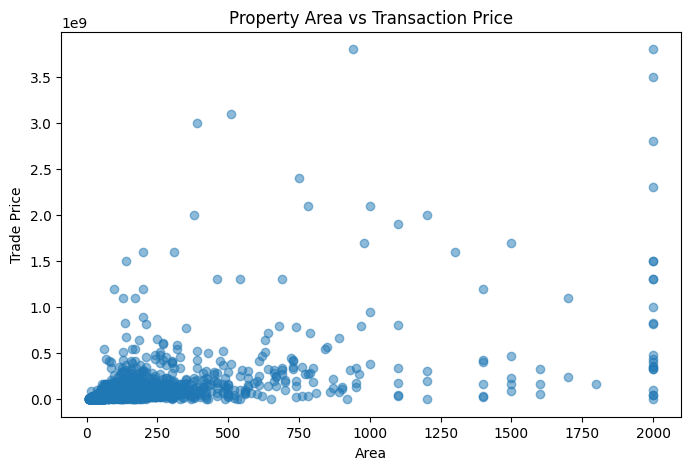

In [17]:
plt.figure(figsize=(8,5))

sample = df.sample(5000)

plt.scatter(sample['Area'], sample['TradePrice'], alpha=0.5)

plt.title('Property Area vs Transaction Price')
plt.xlabel('Area')
plt.ylabel('Trade Price')

plt.show()

This scatterplot shows the relationship between property area and transaction price.

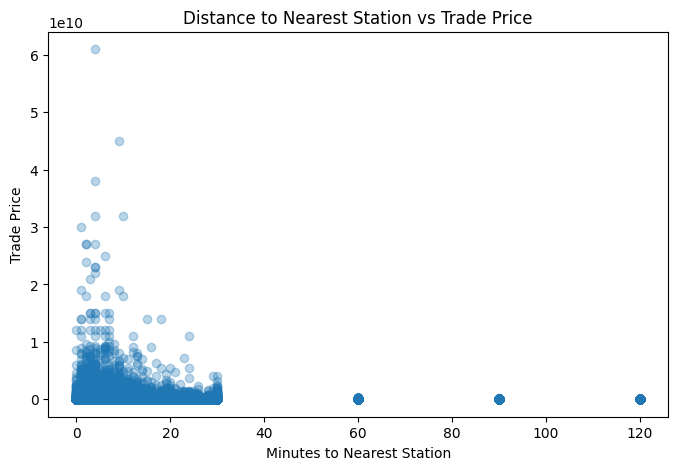

In [18]:
sample = df.dropna(subset=['MinTimeToNearestStation'])

plt.figure(figsize=(8,5))

plt.scatter(
    sample['MinTimeToNearestStation'],
    sample['TradePrice'],
    alpha=0.3
)

plt.title('Distance to Nearest Station vs Trade Price')
plt.xlabel('Minutes to Nearest Station')
plt.ylabel('Trade Price')

plt.show()

The scatter plot of travel time to the nearest station versus transaction price suggests a weak inverse relationship. Properties located closer to a train station generally tend to have higher transaction prices, while properties farther away tend to have lower prices. In addition, most observations are concentrated within the 0–30 minute range, indicating that the majority of properties in this dataset are relatively close to a station. There are also several high-priced outliers, suggesting that factors other than station accessibility may influence property values.

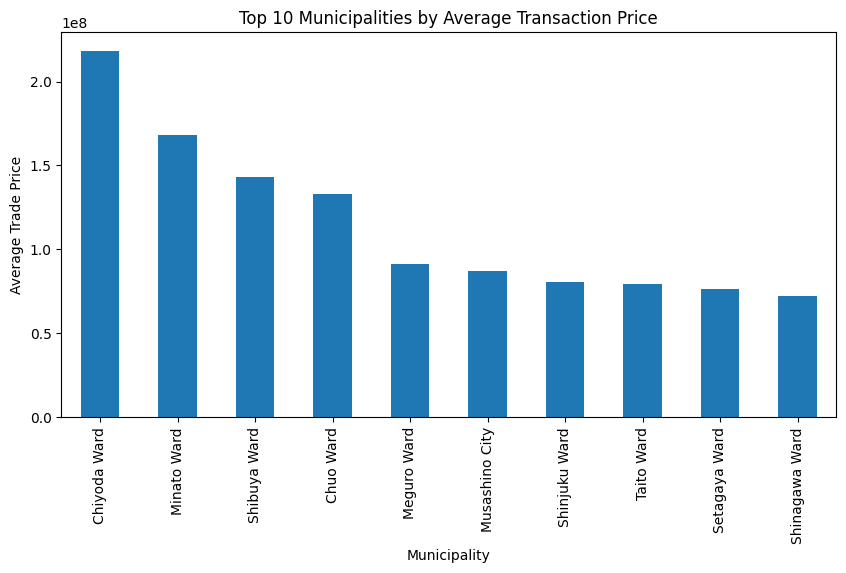

In [19]:
top_areas = (
    df.groupby('Municipality')['TradePrice']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_areas.plot(kind='bar')

plt.title('Top 10 Municipalities by Average Transaction Price')
plt.xlabel('Municipality')
plt.ylabel('Average Trade Price')

plt.show()

The result was surprising because Musashino ranked above Shinjuku in average transaction price. This may reflect characteristics of the sample rather than the overall Tokyo housing market. Because this result was unexpected, I performed additional summary statistics such as the median transaction price and transaction count. The difference may be influenced by outliers, property type composition, or differences in the number of transactions recorded in each municipality.

In [20]:
df['Municipality'].value_counts().head(20)

,count
Municipality,
Setagaya Ward,26304
Ota Ward,22782
Nerima Ward,22193
Adachi Ward,18427
Suginami Ward,17825
Itabashi Ward,15954
Hachioji City,15010
Koto Ward,14632
Edogawa Ward,14308


In [21]:
df.groupby('Municipality')['TradePrice'].agg(['count','mean','median']).sort_values('mean', ascending=False)

,count,mean,median
Municipality,,,
Chiyoda Ward,4230,2.184709e+08,39000000.0
Minato Ward,12429,1.682769e+08,51000000.0
Shibuya Ward,9259,1.428461e+08,44000000.0
Chuo Ward,9686,1.332966e+08,37000000.0
Meguro Ward,8157,9.136712e+07,54000000.0
Musashino City,2930,8.701953e+07,58000000.0
Shinjuku Ward,13958,8.029787e+07,32000000.0
Taito Ward,7923,7.916679e+07,31000000.0
Setagaya Ward,26304,7.667539e+07,54000000.0


Musashino appears to have a high concentration of relatively expensive residential properties. Areas such as Kichijōji are among Tokyo's most desirable residential neighborhoods. Therefore, although Musashino is less famous internationally than central wards such as Shinjuku, the transaction data suggest that property values in Musashino are consistently high.

## New possible EDA

After performing these tests, I started wondering how property values in Shinjuku ward and Musashino city varies, so I added a new exploratory question: Is the average transaction price in Musashino City significantly different from the average transaction price in Shinjuku Ward?

### Hypotheses

Null hypothesis (H₀): The average transaction price is the same in Musashino City and Shinjuku Ward.

Alternative Hypothesis (H₁): The average transaction price differs between Musashino City and Shinjuku Ward.

In [22]:
from scipy.stats import ttest_ind

musashino = df[df['Municipality'] == 'Musashino City']['TradePrice']
shinjuku = df[df['Municipality'] == 'Shinjuku Ward']['TradePrice']

t_stat, p_value = ttest_ind(
    musashino,
    shinjuku,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.640482943146252
p-value: 0.10096012553497563


I conducted a two-sample Welch's t-test to compare average transaction prices between two independent groups, Musashino City and Shinjuku Ward. The test produced a t-statistic of 1.64 and a p-value of 0.101. Because the p-value is greater than the significance level of 0.05, there is insufficient evidence to conclude that the average transaction prices differ significantly between the two municipalities.

Although Musashino City had a higher average transaction price than Shinjuku Ward in the exploratory analysis, the statistical test suggests that this difference may be due to variation within the data rather than a clear difference in population means. This result demonstrates the importance of conducting statistical tests rather than relying solely on descriptive statistics or rankings.

Because the result was not statistically significant, we did not reject the null hypothesis. However, this does not prove that the municipalities have identical average transaction prices. It remains possible that a true difference exists but was not detected by this test (a Type II error).

### Limitations

This analysis is exploratory because the statistical question was developed after examining the dataset. The dataset only includes Tokyo transactions and may not represent the broader Japanese housing market. Real estate prices are highly skewed and contain extreme values, which may affect statistical assumptions. Other factors such as property type, building age, and neighborhood characteristics may influence prices. Therefore, the analysis cannot support causal claims.

## Preliminary EDA Findings

The scatter plot of travel time to the nearest station versus transaction price suggests a weak inverse relationship. Properties located closer to a train station generally tend to have higher transaction prices, while properties farther away tend to have lower prices. In addition, most observations are concentrated within the 0–30 minute range, indicating that the majority of properties in this dataset are relatively close to a station. There are also several high-priced outliers, suggesting that factors other than station accessibility may influence property values.

The distribution of transaction prices is highly skewed to the right. The mean transaction price (approximately ¥65.6 million) is substantially higher than the median transaction price (¥35 million), suggesting the presence of very expensive outlier properties.

Finally, average transaction prices varied considerably across municipalities. One surprising finding was that Musashino City ranked above Shinjuku Ward in average transaction price. Further investigation showed that Musashino also had a higher median transaction price, suggesting that the result was not caused solely by a small number of outliers. These findings suggest that location, property size, and accessibility may all play important roles in determining housing prices.

## AI Use Reference

I used ChatGPT to help understand the assignment requirements, develop exploratory questions, write Python code for exploratory data analysis, create visualizations, and review the appropriateness of statistical methods. I reviewed and edited all outputs before including them in the notebook.